# Task 1 — Dataset Understanding & EDA
**Antlings Internship — VisDrone Human & Car Detection**

This notebook covers:
- Dataset structure overview
- Class distribution analysis
- Object size distribution
- Sample image visualizations with bounding boxes
- Challenges identified in the dataset

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
import pandas as pd
import random

# Paths — AFTER preprocessing
PREPROCESSED = Path('F:/ANTS/outputs/preprocessed')
ORIGINAL     = Path('F:/VisDrone_Dataset')

TRAIN_IMGS = PREPROCESSED / 'train/images'
TRAIN_LBLS = PREPROCESSED / 'train/labels'
VAL_IMGS   = PREPROCESSED / 'val/images'
VAL_LBLS   = PREPROCESSED / 'val/labels'

CLASS_NAMES = {0: 'human', 1: 'car'}
CLASS_COLORS = {0: (0, 255, 0), 1: (0, 0, 255)}  # green=human, red=car

print('Paths set. Ready.')

Paths set. Ready.


## 1. Dataset Size Overview

In [2]:
splits = {
    'train': (PREPROCESSED/'train/images', PREPROCESSED/'train/labels'),
    'val':   (PREPROCESSED/'val/images',   PREPROCESSED/'val/labels'),
    'test':  (PREPROCESSED/'test/images',  PREPROCESSED/'test/labels'),
}

for split, (imgs, lbls) in splits.items():
    n_imgs = len(list(imgs.glob('*.jpg')))
    n_lbls = len(list(lbls.glob('*.txt')))
    print(f'{split:6s}: {n_imgs:5d} images  |  {n_lbls:5d} label files')

train :  6471 images  |   6471 label files
val   :   548 images  |    548 label files
test  :  1610 images  |   1610 label files


## 2. Class Distribution

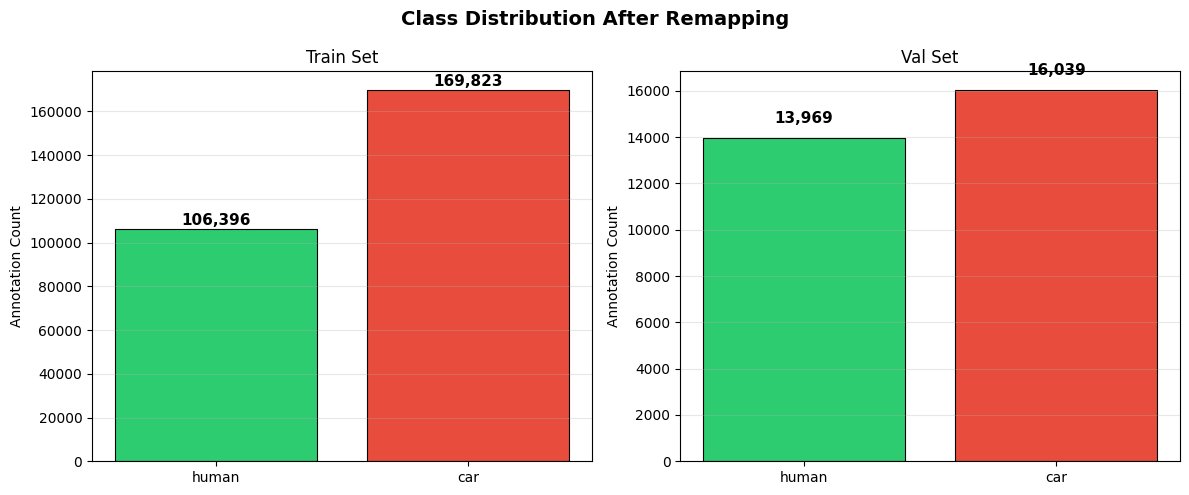

Train — human: 106,396  car: 169,823
Val   — human: 13,969    car: 16,039


In [3]:
def count_classes(label_dir):
    counts = Counter()
    for lbl_file in Path(label_dir).glob('*.txt'):
        for line in lbl_file.read_text().strip().splitlines():
            if line.strip():
                cls = int(line.split()[0])
                counts[cls] += 1
    return counts

train_counts = count_classes(TRAIN_LBLS)
val_counts   = count_classes(VAL_LBLS)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution After Remapping', fontsize=14, fontweight='bold')

for ax, (title, counts) in zip(axes, [('Train Set', train_counts), ('Val Set', val_counts)]):
    labels = [CLASS_NAMES.get(k, str(k)) for k in sorted(counts.keys())]
    values = [counts[k] for k in sorted(counts.keys())]
    colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Annotation Count')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('F:/ANTS/results/images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Train — human: {train_counts[0]:,}  car: {train_counts[1]:,}')
print(f'Val   — human: {val_counts[0]:,}    car: {val_counts[1]:,}')

## 3. Object Size Distribution (Key Challenge)

Computing object sizes (may take ~30 seconds)...


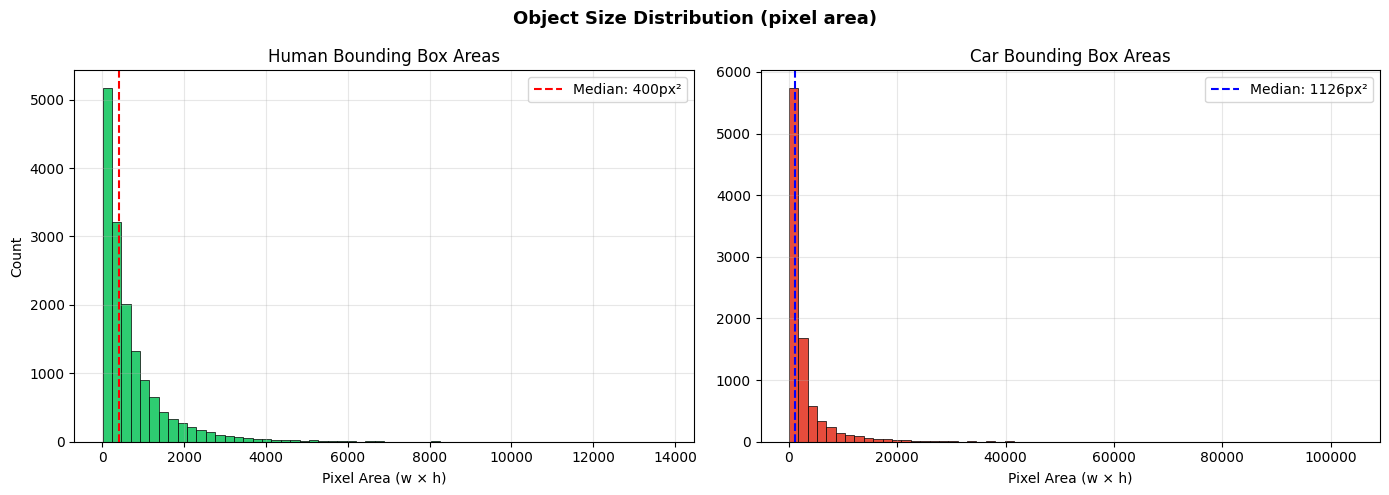

Human median size: 400.0 px²  (very small!)
Car   median size: 1126.0 px²
Humans smaller than 32x32px: 12145/15389 = 78.9%


In [4]:
def get_bbox_sizes(label_dir, img_dir, max_files=500):
    """Collect bounding box pixel areas for all annotations."""
    sizes_human, sizes_car = [], []
    label_files = list(Path(label_dir).glob('*.txt'))[:max_files]

    for lbl_file in label_files:
        img_file = Path(img_dir) / (lbl_file.stem + '.jpg')
        if not img_file.exists():
            continue
        img = cv2.imread(str(img_file))
        if img is None:
            continue
        H, W = img.shape[:2]

        for line in lbl_file.read_text().strip().splitlines():
            if not line.strip():
                continue
            parts = line.split()
            cls = int(parts[0])
            bw  = float(parts[3]) * W
            bh  = float(parts[4]) * H
            area = bw * bh
            if cls == 0:
                sizes_human.append(area)
            else:
                sizes_car.append(area)
    return sizes_human, sizes_car

print('Computing object sizes (may take ~30 seconds)...')
sizes_human, sizes_car = get_bbox_sizes(TRAIN_LBLS, TRAIN_IMGS, max_files=300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Object Size Distribution (pixel area)', fontsize=13, fontweight='bold')

axes[0].hist(sizes_human, bins=60, color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].set_title('Human Bounding Box Areas')
axes[0].set_xlabel('Pixel Area (w × h)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.median(sizes_human), color='red', linestyle='--',
                label=f'Median: {np.median(sizes_human):.0f}px²')
axes[0].legend()

axes[1].hist(sizes_car, bins=60, color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Car Bounding Box Areas')
axes[1].set_xlabel('Pixel Area (w × h)')
axes[1].axvline(np.median(sizes_car), color='blue', linestyle='--',
                label=f'Median: {np.median(sizes_car):.0f}px²')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F:/ANTS/results/images/object_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Human median size: {np.median(sizes_human):.1f} px²  (very small!)')
print(f'Car   median size: {np.median(sizes_car):.1f} px²')
tiny_human = sum(1 for s in sizes_human if s < 32*32)
print(f'Humans smaller than 32x32px: {tiny_human}/{len(sizes_human)} = {100*tiny_human/len(sizes_human):.1f}%')

## 4. Sample Visualizations with Bounding Boxes

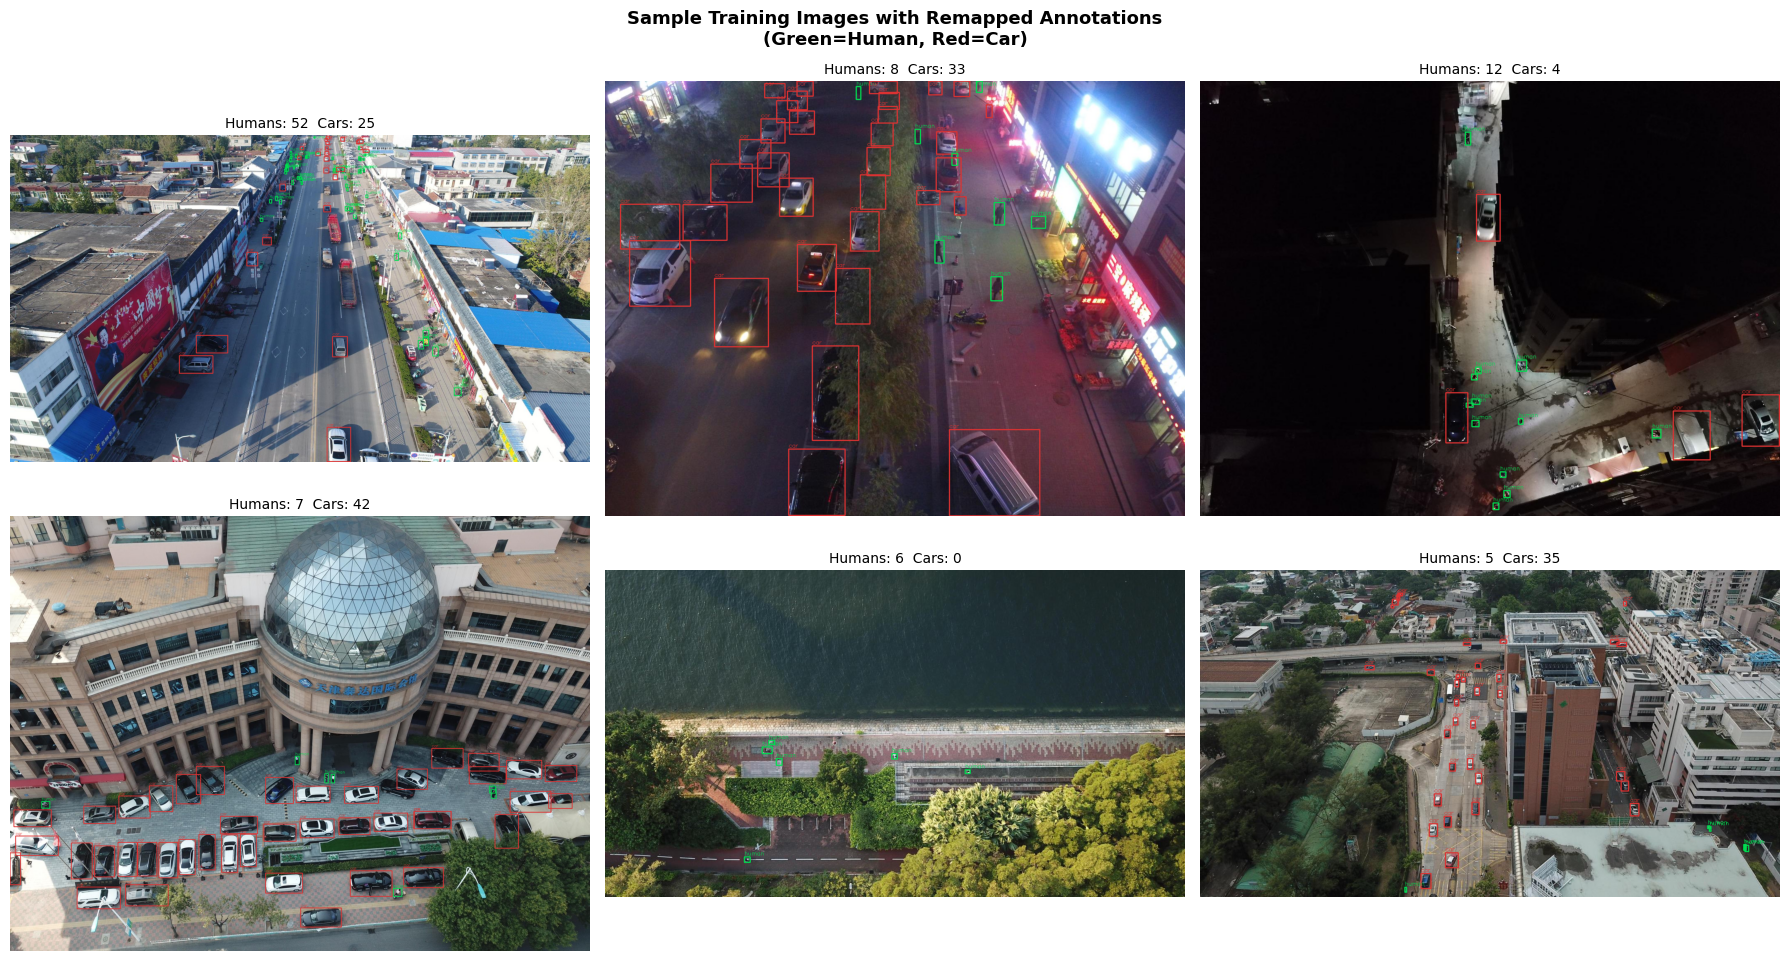

In [5]:
def draw_boxes_on_image(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    if Path(lbl_path).exists():
        for line in Path(lbl_path).read_text().strip().splitlines():
            if not line.strip():
                continue
            parts = line.split()
            cls = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = int((cx - bw/2) * W)
            y1 = int((cy - bh/2) * H)
            x2 = int((cx + bw/2) * W)
            y2 = int((cy + bh/2) * H)
            color = (0, 220, 80) if cls == 0 else (220, 50, 50)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = CLASS_NAMES.get(cls, str(cls))
            cv2.putText(img, label, (x1, max(y1-4, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return img

# Pick 6 random training images
all_imgs = list(TRAIN_IMGS.glob('*.jpg'))
sample_imgs = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sample Training Images with Remapped Annotations\n(Green=Human, Red=Car)',
             fontsize=13, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample_imgs):
    lbl_path = TRAIN_LBLS / (img_path.stem + '.txt')
    annotated = draw_boxes_on_image(img_path, lbl_path)

    # Count annotations
    n_human, n_car = 0, 0
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            if line.strip():
                if int(line.split()[0]) == 0: n_human += 1
                else: n_car += 1

    ax.imshow(annotated)
    ax.set_title(f'Humans: {n_human}  Cars: {n_car}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('F:/ANTS/results/images/sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Annotations Per Image Distribution

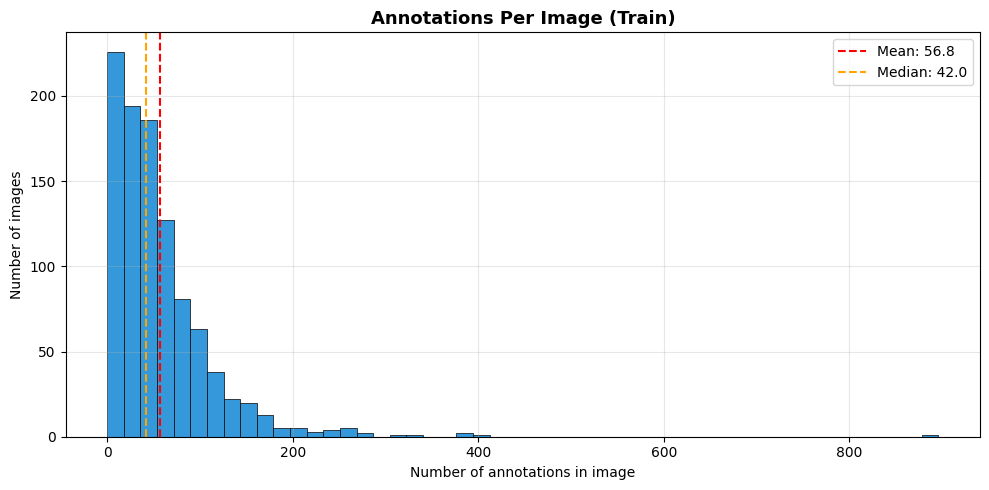

Mean annotations per image:   56.8
Median annotations per image: 42.0
Max annotations in one image: 896


In [6]:
ann_per_img = []
for lbl in list(TRAIN_LBLS.glob('*.txt'))[:1000]:
    lines = [l for l in lbl.read_text().strip().splitlines() if l.strip()]
    ann_per_img.append(len(lines))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ann_per_img, bins=50, color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_title('Annotations Per Image (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of annotations in image')
ax.set_ylabel('Number of images')
ax.axvline(np.mean(ann_per_img), color='red', linestyle='--',
           label=f'Mean: {np.mean(ann_per_img):.1f}')
ax.axvline(np.median(ann_per_img), color='orange', linestyle='--',
           label=f'Median: {np.median(ann_per_img):.1f}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('F:/ANTS/results/images/annotations_per_image.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean annotations per image:   {np.mean(ann_per_img):.1f}')
print(f'Median annotations per image: {np.median(ann_per_img):.1f}')
print(f'Max annotations in one image: {max(ann_per_img)}')

## 6. Dataset Challenges Summary

Based on the analysis above, key challenges in VisDrone are:

1. **Very small objects** — Most humans occupy less than 32×32 pixels. Standard YOLO at 640px resolution struggles severely with these. Solution: use imgsz=1280 and SAHI during inference.

2. **Class imbalance** — There are far more human annotations than car annotations. Solution: augmentation and weighted loss.

3. **High density scenes** — Some images contain 50+ humans in tight clusters, making individual detection difficult.

4. **Varying altitude & viewpoint** — Drone altitude changes dramatically between clips, affecting apparent object size.

5. **Lighting variation** — Night scenes, shadows, and overexposed areas reduce visibility.

6. **Camera motion** — Drone movement causes motion blur and background shift, critical for tracking.

**Our solutions:**
- Train at imgsz=1280 (higher resolution preserves tiny object pixels)
- SAHI slicing during inference for dense scenes
- BoT-SORT tracker (has Camera Motion Compensation for drone footage)
- Class remapping: pedestrian + people → human, car + van → car

In [7]:
print('EDA Complete!')
print('Saved charts to: F:/ANTS/results/images/')
print()
print('Next step: Run scripts/train.py')

EDA Complete!
Saved charts to: F:/ANTS/results/images/

Next step: Run scripts/train.py
